In [1]:
from google.colab import drive
try:
  drive.mount('/content/drive')
  print('Kết nối với Drive thành công')
except Exception as ex:
  print(f'Có lỗi khi kết nối: {ex}')
  exit()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kết nối với Drive thành công


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Dang quet du lieu: /content/drive/MyDrive/HK1-20252026/Steganography/Data/audio-cats-and-dogs
Da xu ly xong 277 file.


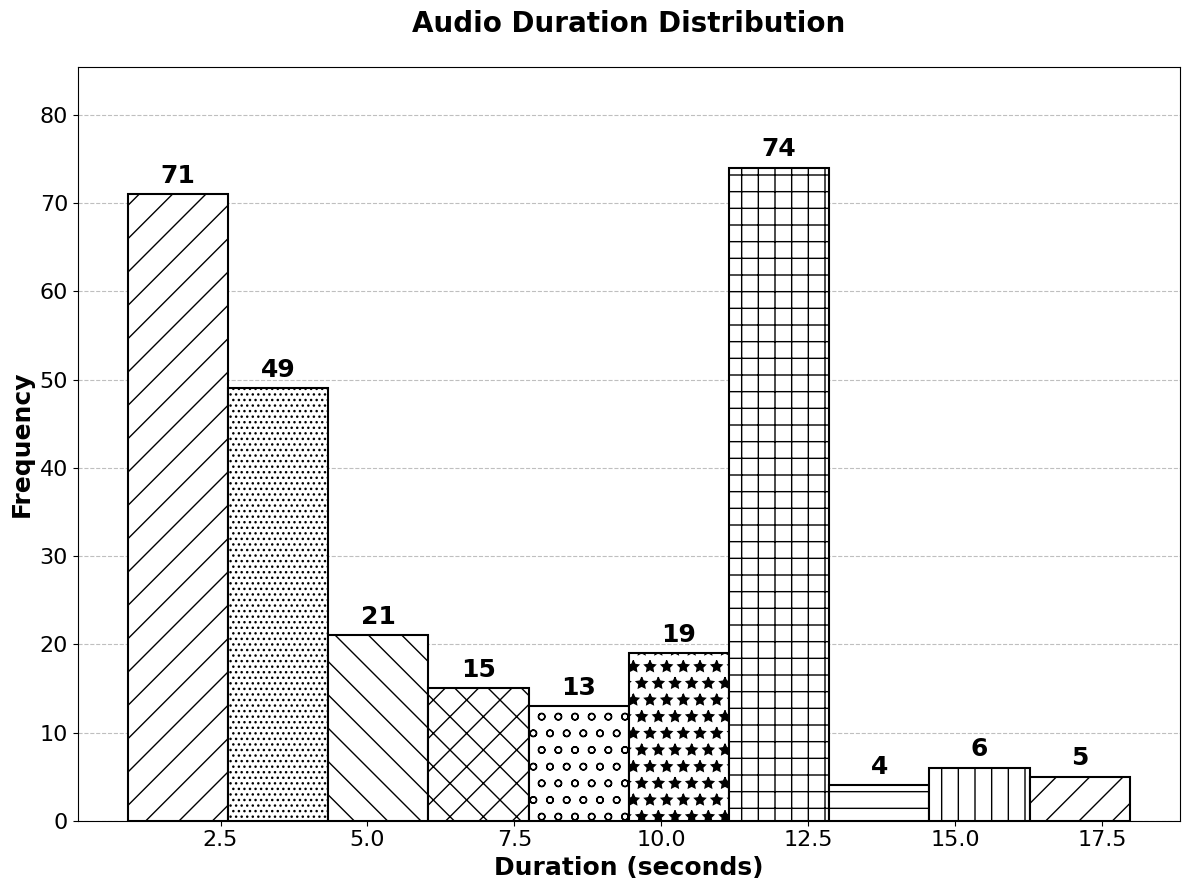

Da luu bieu do: Histogram_Duration_Recursive.png


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pydub import AudioSegment
import warnings

warnings.filterwarnings("ignore")

folder_path = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/audio-cats-and-dogs'
output_image = 'Histogram_Duration_Recursive.png'

data = []

if os.path.exists(folder_path):
    print(f"Dang quet du lieu: {folder_path}")

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a')):
                filepath = os.path.join(root, filename)
                try:
                    audio = AudioSegment.from_file(filepath)
                    data.append(audio.duration_seconds)
                except:
                    continue

    print(f"Da xu ly xong {len(data)} file.")
else:
    print(f"Thu muc khong ton tai: {folder_path}")

if data:
    df = pd.DataFrame(data, columns=['Duration'])

    fig, ax = plt.subplots(figsize=(12, 9))

    num_bins = int(np.ceil(np.log2(len(df)) + 1))
    if num_bins < 5: num_bins = 5

    counts, bins, patches = ax.hist(df['Duration'], bins=num_bins,
                                    color='white', edgecolor='black', linewidth=1.5)

    patterns = ['/', '...', '\\', 'x', 'o', '*', '+', '-', '|']

    for i, patch in enumerate(patches):
        pattern = patterns[i % len(patterns)]
        patch.set_hatch(pattern)

    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 1.1)

    for count, patch in zip(counts, patches):
        if count > 0:
            height = patch.get_height()
            x_pos = patch.get_x() + patch.get_width() / 2
            ax.text(x_pos, height + (max(counts) * 0.01),
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

    ax.set_xlabel('Duration (seconds)', fontsize=18, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=18, fontweight='bold')
    ax.set_title('Audio Duration Distribution', fontsize=20, fontweight='bold', pad=25)

    ax.tick_params(axis='both', which='major', labelsize=16)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.5)

    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    plt.show()
    print(f"Da luu bieu do: {output_image}")
else:
    print("Khong tim thay du lieu audio hop le.")

Dang quet du lieu: /content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq
Da xu ly xong 750 file.


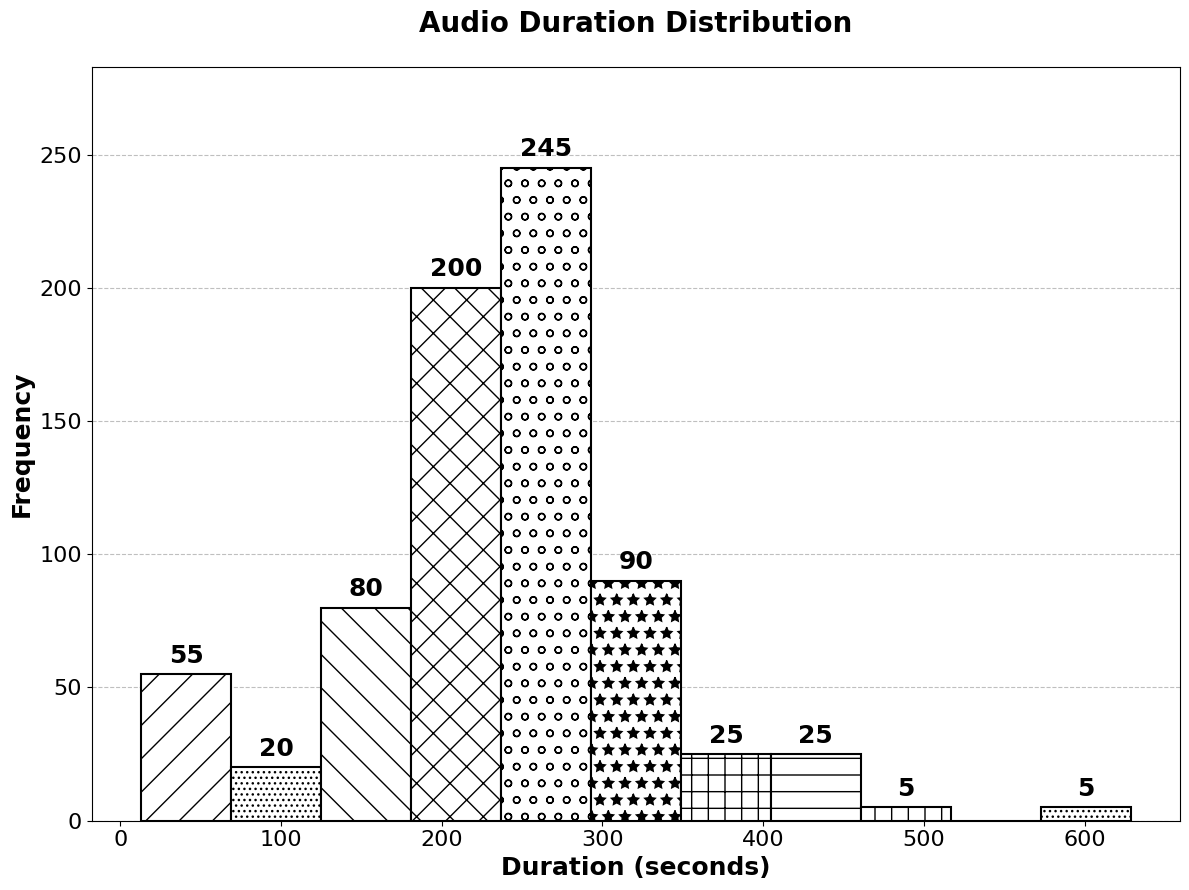

Da luu bieu do: Histogram_Duration_Optimized.png


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import librosa
import warnings

warnings.filterwarnings("ignore")

folder_path = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq'
output_image = 'Histogram_Duration_Optimized.png'

data = []

if os.path.exists(folder_path):
    print(f"Dang quet du lieu: {folder_path}")

    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.wav', '.mp3', '.flac', '.ogg', '.m4a')):
                filepath = os.path.join(root, filename)
                try:
                    duration = librosa.get_duration(path=filepath)
                    data.append(duration)
                except TypeError:
                    try:
                        duration = librosa.get_duration(filename=filepath)
                        data.append(duration)
                    except:
                        continue
                except:
                    continue

    print(f"Da xu ly xong {len(data)} file.")
else:
    print(f"Thu muc khong ton tai: {folder_path}")

if data:
    df = pd.DataFrame(data, columns=['Duration'])

    fig, ax = plt.subplots(figsize=(12, 9))

    num_bins = int(np.ceil(np.log2(len(df)) + 1))
    if num_bins < 5: num_bins = 5

    counts, bins, patches = ax.hist(df['Duration'], bins=num_bins,
                                    color='white', edgecolor='black', linewidth=1.5)

    patterns = ['/', '...', '\\', 'x', 'o', '*', '+', '-', '|']

    for i, patch in enumerate(patches):
        pattern = patterns[i % len(patterns)]
        patch.set_hatch(pattern)

    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1] * 1.1)

    for count, patch in zip(counts, patches):
        if count > 0:
            height = patch.get_height()
            x_pos = patch.get_x() + patch.get_width() / 2
            ax.text(x_pos, height + (max(counts) * 0.01),
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

    ax.set_xlabel('Duration (seconds)', fontsize=18, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=18, fontweight='bold')
    ax.set_title('Audio Duration Distribution', fontsize=20, fontweight='bold', pad=25)

    ax.tick_params(axis='both', which='major', labelsize=16)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.5)

    plt.tight_layout()
    plt.savefig(output_image, dpi=300)
    plt.show()
    print(f"Da luu bieu do: {output_image}")
else:
    print("Khong tim thay du lieu audio hop le.")